In [13]:
import pandas as pd
import glob
import datetime
from zoneinfo import ZoneInfo
import exchange_calendars as ec
import torch
import os
import numpy as np

In [15]:

def is_full_nyse_day(date):
    nyse = ec.get_calendar("XNYS")
    date = pd.Timestamp(date).normalize()

    if not nyse.is_session(date):
        return False

    open_time   = nyse.session_open(date)
    close_time  = nyse.session_close(date)
    full_length = pd.Timedelta(hours=6.5)
    return (close_time - open_time) >= full_length


def get_full_sequence_data_by_day():

    folder_path      = r"../../../MarketData/historical_data"
    files            = glob.glob(os.path.join(folder_path, "spy_1min_*.csv"))

    xs = []

    for file in files:

        date_str = file.split("_")[-1].split(".")[0]
        print(date_str)
        date_str = date_str[:4] + "-" + date_str[4:6] + "-" + date_str[6:]

        if not is_full_nyse_day(date_str):
            print("skipping", date_str)
            continue

        df = pd.read_csv(file)

        open_time = datetime.datetime.strptime(date_str + " 09:31:00", "%Y-%m-%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))
        close_time = datetime.datetime.strptime(date_str + " 16:00:00", "%Y-%m-%d %H:%M:%S").replace(tzinfo= ZoneInfo("America/New_York"))

        df["ts_recv"] = pd.to_datetime(df["ts_recv"])
        df['ts_recv_est'] = df['ts_recv'].dt.tz_convert('America/New_York')
        df = df[(df["ts_recv_est"] >= open_time) & (df["ts_recv_est"] <= close_time)]
        df["seconds_since_open"] = (df["ts_recv_est"] - open_time).dt.total_seconds()
        data = df[["ret_60s"]] #, "rv_60s", "seconds_since_open"]].values

        data = np.array(data)
        xs.append(data)

    xs = np.array(xs)
    return  xs


In [16]:
returns = get_full_sequence_data_by_day()
returns = torch.from_numpy(returns)   # shape (1246, 390)
print(returns.shape)

20201005
20201006
20201007
20201008
20201009
20201012
20201013
20201014
20201015
20201016
20201019
20201020
20201021
20201022
20201023
20201026
20201027
20201028
20201029
20201030
20201102
20201103
20201104
20201105
20201106
20201109
20201110
20201111
20201112
20201113
20201116
20201117
20201118
20201119
20201120
20201123
20201124
20201125
20201127
skipping 2020-11-27
20201130
20201201
20201202
20201203
20201204
20201207
20201208
20201209
20201210
20201211
20201214
20201215
20201216
20201217
20201218
20201221
20201222
20201223
20201224
skipping 2020-12-24
20201228
20201229
20201230
20201231
20210104
20210105
20210106
20210107
20210108
20210111
20210112
20210113
20210114
20210115
20210119
20210120
20210121
20210122
20210125
20210126
20210127
20210128
20210129
20210201
20210202
20210203
20210204
20210205
20210208
20210209
20210210
20210211
20210212
20210216
20210217
20210218
20210219
20210222
20210223
20210224
20210225
20210226
20210301
20210302
20210303
20210304
20210305
20210308
202103

In [17]:
import torch

num_days, num_minutes, _ = returns.shape
context = 60

Xs = []
ys = []

for d in range(num_days):
    day = returns[d]
    x = day[:-1]
    y = day[1:]
    Xs.append(x)
    ys.append(y)

Xs = torch.stack(Xs)     # (1246, 389, 1)
ys = torch.stack(ys)     # (1246, 389, 1)
print(Xs.shape, ys.shape)

torch.Size([1246, 389, 1]) torch.Size([1246, 389, 1])


In [18]:
N = Xs.shape[0]

train_end = int(0.6 * N)
val_end   = int(0.8 * N)

Xs_train_raw = Xs[:train_end]
ys_train_raw = ys[:train_end]

Xs_val_raw = Xs[train_end:val_end]
ys_val_raw = ys[train_end:val_end]

Xs_test_raw = Xs[val_end:]
ys_test_raw = ys[val_end:]

mean_train = Xs_train_raw.mean()
std_train  = Xs_train_raw.std()

Xs_train = (Xs_train_raw - mean_train) / std_train
Xs_val   = (Xs_val_raw   - mean_train) / std_train
Xs_test  = (Xs_test_raw  - mean_train) / std_train

ys_train = (ys_train_raw - mean_train) / std_train
ys_val   = (ys_val_raw   - mean_train) / std_train
ys_test  = (ys_test_raw  - mean_train) / std_train

print("Train:", Xs_train.shape, ys_train.shape)
print("Val:  ", Xs_val.shape,   ys_val.shape)
print("Test: ", Xs_test.shape,  ys_test.shape)

Train: torch.Size([747, 389, 1]) torch.Size([747, 389, 1])
Val:   torch.Size([249, 389, 1]) torch.Size([249, 389, 1])
Test:  torch.Size([250, 389, 1]) torch.Size([250, 389, 1])


In [19]:
import torch.nn as nn
import torch.nn.functional as F

class LSTMNormal(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            num_layers=1,
            batch_first=True
        )
        self.mu_head = nn.Linear(hidden, 1)
        self.sigma_head = nn.Linear(hidden, 1)

    def forward(self, x):

        out, _ = self.lstm(x)
        h      = out[:, :, :]
        mu     = torch.zeros(out.size(0), out.size(1), 1, device=out.device)
        sigma  = F.softplus(self.sigma_head(h)) + 1e-6
        return mu, sigma

def nll_normal(y, mu, sigma):
    return (
        0.5 * torch.log(2 * torch.pi * sigma**2) +
        (y - mu)**2 / (2 * sigma**2)
    ).mean()


In [20]:
from torch.utils.data import Dataset, DataLoader

class ReturnDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = ReturnDataset(Xs_train, ys_train)
val_ds   = ReturnDataset(Xs_val,   ys_val)
test_ds  = ReturnDataset(Xs_test,  ys_test)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)


In [28]:
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

loss_history      = []
sigma_history     = []

val_loss_history  = []
val_sigma_history = []

model = LSTMNormal().to(device).double()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(300):

    model.train()
    epoch_losses = []

    for xb, yb in train_loader:
        xb, yb = xb.to(device).double(), yb.to(device).double()

        mu, sigma = model(xb)
        loss = nll_normal(yb, mu, sigma)

        epoch_losses.append(loss.item())

        opt.zero_grad()
        loss.backward()
        opt.step()

    loss_history.append(np.mean(epoch_losses))

    train_sigma_curve = sigma.mean(dim=0).squeeze().detach().cpu().numpy()   # (389,)
    sigma_history.append(train_sigma_curve)

    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device).double()
            yb = yb.to(device).double()

            mu, sigma = model(xb)
            val_loss = nll_normal(yb, mu, sigma)

            val_losses.append(val_loss.item())

        val_sigma_curve = sigma.mean(dim=0).squeeze().detach().cpu().numpy()   # (389,)
        val_sigma_history.append(val_sigma_curve)
        val_loss_history.append(np.mean(val_losses))

    print(f"Epoch {epoch}: "
          f"train loss={loss_history[-1]:.4f}, "
          f"val loss={val_loss_history[-1]:.4f}, "
          f"train sigma (mean)={train_sigma_curve.mean():.4f}, "
          f"val sigma (mean)={val_sigma_curve.mean():.4f}")


Epoch 0: train loss=1.5007, val loss=1.1517, train sigma (mean)=0.9599, val sigma (mean)=0.9721
Epoch 1: train loss=1.4081, val loss=1.1318, train sigma (mean)=0.9452, val sigma (mean)=0.9428
Epoch 2: train loss=1.3769, val loss=1.1112, train sigma (mean)=1.0010, val sigma (mean)=0.9438
Epoch 3: train loss=1.2700, val loss=1.0011, train sigma (mean)=1.0709, val sigma (mean)=0.8318
Epoch 4: train loss=1.2304, val loss=0.9592, train sigma (mean)=0.7850, val sigma (mean)=0.7092
Epoch 5: train loss=1.1967, val loss=0.9353, train sigma (mean)=0.8118, val sigma (mean)=0.7033
Epoch 6: train loss=1.1792, val loss=0.9319, train sigma (mean)=0.7204, val sigma (mean)=0.7517
Epoch 7: train loss=1.1726, val loss=0.9305, train sigma (mean)=0.8383, val sigma (mean)=0.7567
Epoch 8: train loss=1.1737, val loss=0.9224, train sigma (mean)=0.9301, val sigma (mean)=0.7398
Epoch 9: train loss=1.1670, val loss=0.9169, train sigma (mean)=0.7832, val sigma (mean)=0.7195
Epoch 10: train loss=1.1630, val loss=0.

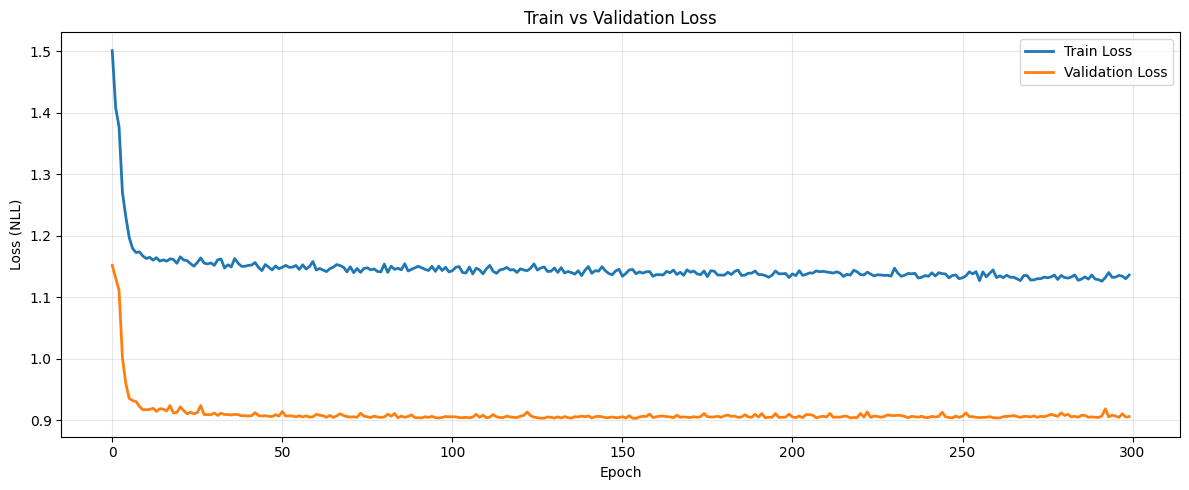

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(loss_history, label="Train Loss", linewidth=2)
plt.plot(val_loss_history, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (NLL)")
plt.title("Train vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

(300, 389)


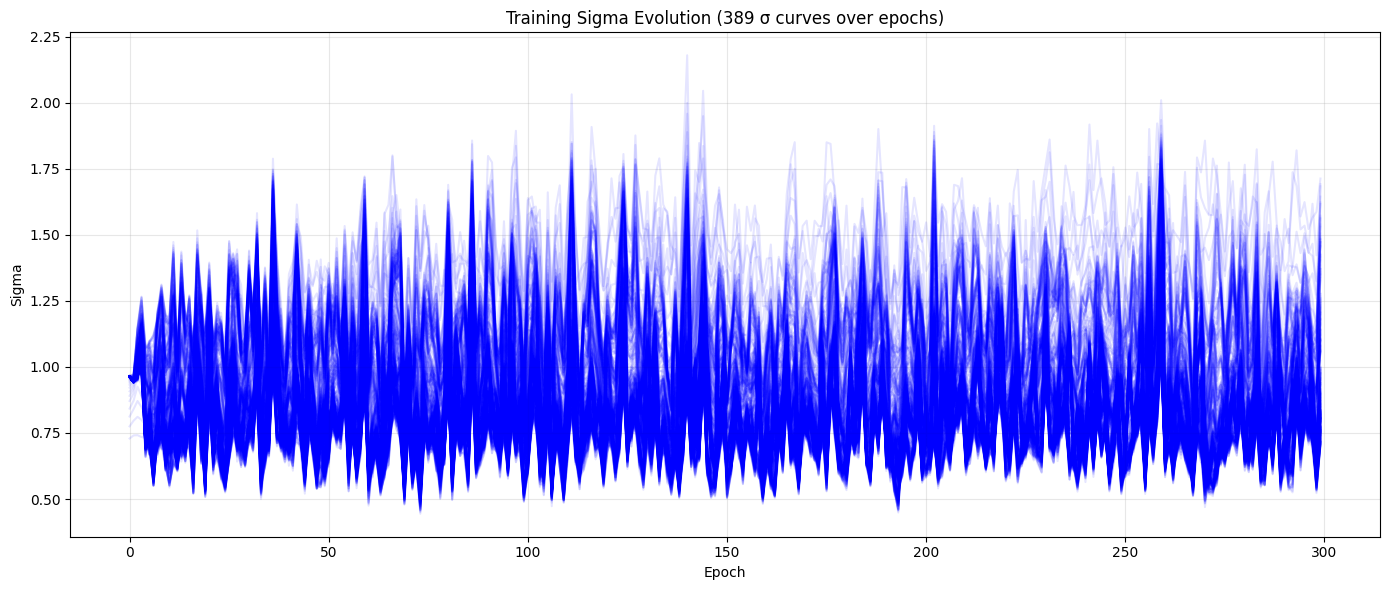

In [30]:

sigma_mat_train = np.stack(sigma_history)  # shape (epochs, 389)
print(sigma_mat_train.shape)
plt.figure(figsize=(14,6))
for minute in range(sigma_mat_train.shape[1]):
    plt.plot(sigma_mat_train[:, minute], alpha=0.1, color='blue')
plt.xlabel("Epoch")
plt.ylabel("Sigma")
plt.title("Training Sigma Evolution (389 σ curves over epochs)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


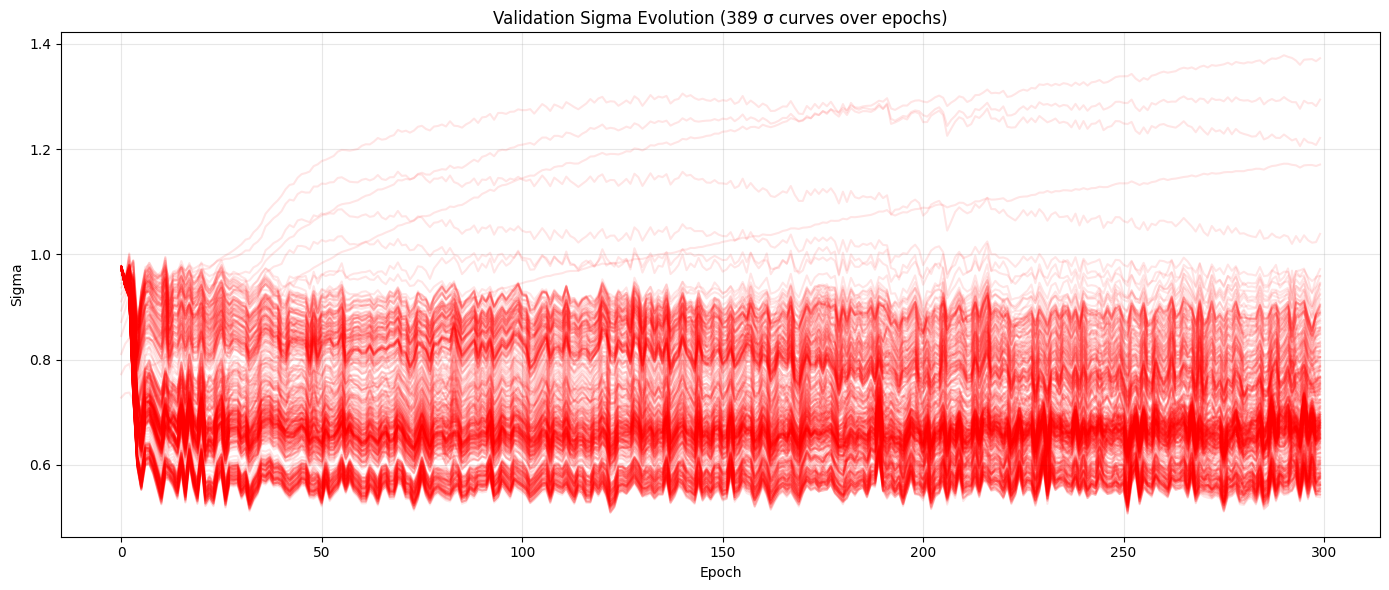

In [31]:
sigma_mat_val = np.stack(val_sigma_history)  # shape (epochs, 389)

plt.figure(figsize=(14,6))
for minute in range(sigma_mat_val.shape[1]):
    plt.plot(sigma_mat_val[:, minute], alpha=0.1, color='red')
plt.xlabel("Epoch")
plt.ylabel("Sigma")
plt.title("Validation Sigma Evolution (389 σ curves over epochs)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


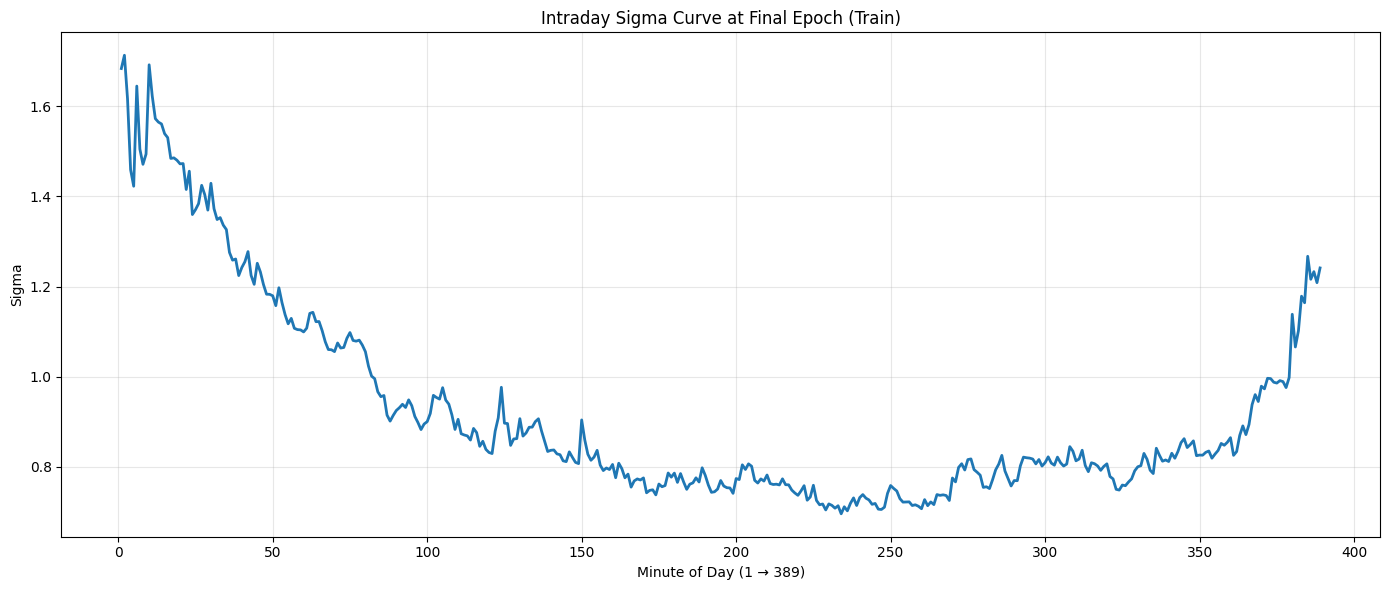

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Get sigma curve from the final epoch
last_sigma_curve = sigma_history[-1]      # shape (389,)

# x-axis = minute index (1 to 389)
minutes = np.arange(1, len(last_sigma_curve) + 1)

plt.figure(figsize=(14, 6))
plt.plot(minutes, last_sigma_curve, linewidth=2)

plt.xlabel("Minute of Day (1 → 389)")
plt.ylabel("Sigma")
plt.title("Intraday Sigma Curve at Final Epoch (Train)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


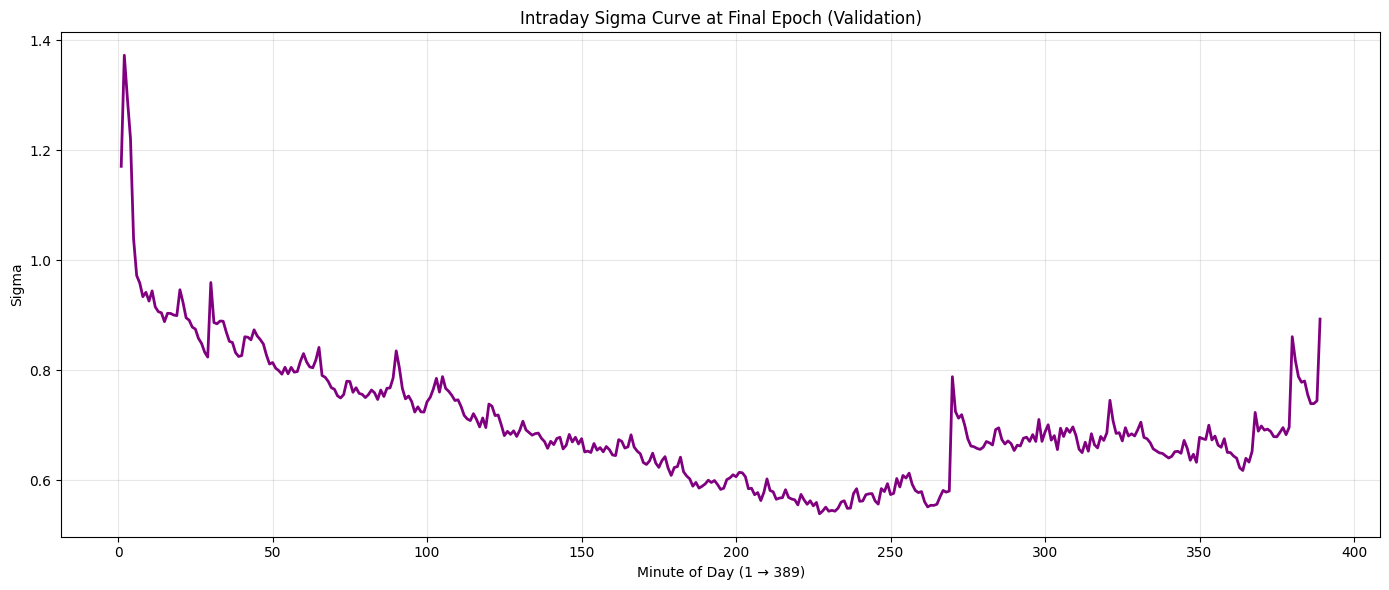

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Get sigma curve from the final epoch (VALIDATION)
last_val_sigma_curve = val_sigma_history[-1]     # shape (389,)

# x-axis: minute 1 → 389
minutes = np.arange(1, len(last_val_sigma_curve) + 1)

plt.figure(figsize=(14, 6))
plt.plot(minutes, last_val_sigma_curve, linewidth=2, color='purple')

plt.xlabel("Minute of Day (1 → 389)")
plt.ylabel("Sigma")
plt.title("Intraday Sigma Curve at Final Epoch (Validation)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
